--- 独立运行几何生成与三视图可视化模块 ---
正在生成几何体网格...
网格生成完毕。

正在生成三视图...请查看弹出的 Matplotlib 窗口。


/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from current font.

/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from current font.

/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.

/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 20463 (\N{CJK UNIFIED IDEOGRAPH-4FEF}) missing from current font.

/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from current font.

/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from current font.

/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from current font.

/tmp/ipykernel_26268/4170798065.py:162: UserWarning:

Glyph 20960 (\N{CJK UNIFIED IDEOGRAPH-51E0}) missing from

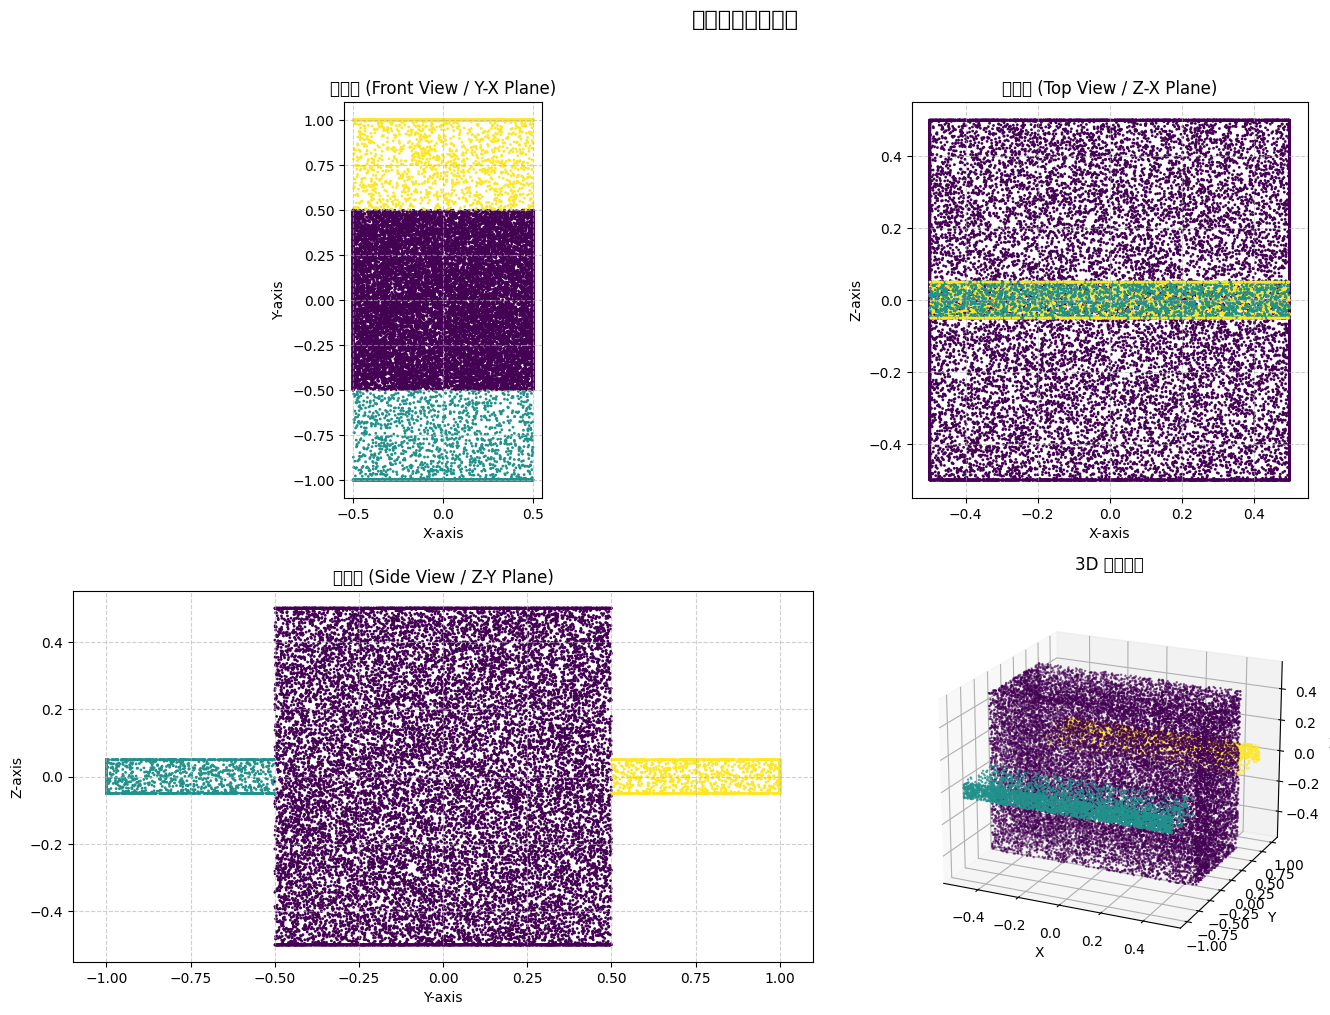


--- 模块测试完毕 ---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

def generate_winged_block_mesh(n_interior=5000, n_boundary_face=500):
    """
    生成一个“带翅膀的方块”几何体的网格点。
    该形状由一个中心方块和两个侧翼组成。
    （此函数内容与之前完全相同，此处省略以保持简洁）
    """
    # 1. 定义几何形状尺寸
    main_x = [-0.5, 0.5]  # 长度 1.0
    main_y = [-0.5, 0.5]  # 长度 1.0
    main_z = [-0.5, 0.5]  # 长度 1.0
    
    # 翅膀的定义
    # x 范围与主体保持一致或稍短，以确保连接
    wing_x = [-0.5, 0.5]
    # y 范围定义了翅膀的位置和宽度
    wing_y_left = [-1.0, -0.5]  # 左翼
    wing_y_right = [0.5, 1.0]   # 右翼
    # z 范围定义翅膀的厚度，使其变得“更薄”
    wing_z = [-0.05, 0.05] # 厚度从 0.2 ([-0.1, 0.1]) 减小到 0.1

    # 辅助函数：检查一个点是否在几何体内
    def is_inside(p):
        x, y, z = p[:, 0], p[:, 1], p[:, 2]
        in_main = (x >= main_x[0]) & (x <= main_x[1]) & (y >= main_y[0]) & (y <= main_y[1]) & (z >= main_z[0]) & (z <= main_z[1])
        in_left_wing = (x >= wing_x[0]) & (x <= wing_x[1]) & (y >= wing_y_left[0]) & (y <= wing_y_left[1]) & (z >= wing_z[0]) & (z <= wing_z[1])
        in_right_wing = (x >= wing_x[0]) & (x <= wing_x[1]) & (y >= wing_y_right[0]) & (y <= wing_y_right[1]) & (z >= wing_z[0]) & (z <= wing_z[1])
        return in_main | in_left_wing | in_right_wing

    # 2. 生成内部点 (使用拒绝采样)
    bounding_box = np.array([
        [min(main_x[0], wing_x[0]), max(main_x[1], wing_x[1])],
        [wing_y_left[0], wing_y_right[1]],
        [main_z[0], main_z[1]]
    ])
    
    interior_points = []
    while len(interior_points) < n_interior:
        n_sample = (n_interior - len(interior_points)) * 2
        points = bounding_box[:, 0] + (bounding_box[:, 1] - bounding_box[:, 0]) * np.random.rand(n_sample, 3)
        valid_points = points[is_inside(points)]
        interior_points.extend(valid_points)
    x_interior = np.array(interior_points[:n_interior])

    # 3. 生成边界点
    def generate_face_points(n_pts, fixed_dim, fixed_val, dim1_range, dim2_range):
        pts = np.random.rand(n_pts, 2)
        pts[:, 0] = dim1_range[0] + (dim1_range[1] - dim1_range[0]) * pts[:, 0]
        pts[:, 1] = dim2_range[0] + (dim2_range[1] - dim2_range[0]) * pts[:, 1]
        
        full_pts = np.full((n_pts, 3), fixed_val)
        dims = [0, 1, 2]
        data_dims = [d for d in dims if d != fixed_dim]
        full_pts[:, data_dims[0]] = pts[:, 0]
        full_pts[:, data_dims[1]] = pts[:, 1]
        return full_pts

    x1u = generate_face_points(n_boundary_face, 0, main_x[1], main_y, main_z)
    x1b = generate_face_points(n_boundary_face, 0, main_x[0], main_y, main_z)
    x2u = generate_face_points(n_boundary_face, 1, wing_y_right[1], wing_x, wing_z)
    x2b = generate_face_points(n_boundary_face, 1, wing_y_left[0], wing_x, wing_z)

    n_main = int(n_boundary_face * 0.7)
    n_wing = (n_boundary_face - n_main) // 2
    
    x3u_main = generate_face_points(n_main, 2, main_z[1], main_x, main_y)
    x3u_lwing = generate_face_points(n_wing, 2, wing_z[1], wing_x, wing_y_left)
    x3u_rwing = generate_face_points(n_wing + (n_boundary_face - n_main - 2 * n_wing), 2, wing_z[1], wing_x, wing_y_right)
    x3u = np.vstack([x3u_main, x3u_lwing, x3u_rwing])

    x3b_main = generate_face_points(n_main, 2, main_z[0], main_x, main_y)
    x3b_lwing = generate_face_points(n_wing, 2, wing_z[0], wing_x, wing_y_left)
    x3b_rwing = generate_face_points(n_wing + (n_boundary_face - n_main - 2 * n_wing), 2, wing_z[0], wing_x, wing_y_right)
    x3b = np.vstack([x3b_main, x3b_lwing, x3b_rwing])

    mesh_data = {
        'x': x_interior, 'x1u': x1u, 'x1b': x1b,
        'x2u': x2u, 'x2b': x2b, 'x3u': x3u, 'x3b': x3b,
        'n': np.array([[x_interior.shape[0]]])
    }
    
    return mesh_data

# ==============================================================================
# ✨ 静态三视图可视化函数 ✨
# ==============================================================================
def visualize_geometry_three_views(mesh_data):
    """
    使用 Matplotlib 创建一个包含三个2D投影视图的静态图来检查几何体的连续性。

    参数:
        mesh_data (dict): 从 generate_winged_block_mesh 返回的字典。
    """
    # 将所有点合并，并为每个点分配一个类别标签用于着色
    # 0: 内部, 1: 主体, 2: 左翼, 3: 右翼
    points = []
    colors = []

    # 定义几何尺寸以便分类
    main_y, wing_y_left, wing_y_right = [-0.5, 0.5], [-1.0, -0.5], [0.5, 1.0]

    all_points = np.vstack(list(mesh_data.values())[:-1]) # 合并所有坐标点

    for p in all_points:
        points.append(p)
        y = p[1]
        if main_y[0] <= y <= main_y[1]:
            colors.append(1) # 主体
        elif wing_y_left[0] <= y < main_y[0]:
            colors.append(2) # 左翼
        elif main_y[1] < y <= wing_y_right[1]:
            colors.append(3) # 右翼
        else:
            colors.append(0) # 理论上不应该有其他点
            
    points = np.array(points)
    colors = np.array(colors)

    # 创建一个 2x2 的子图网格
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)

    # 主视图 (Front View, X-Y plane)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(points[:, 0], points[:, 1], c=colors, s=1, cmap='viridis')
    ax1.set_title('主视图 (Front View / Y-X Plane)')
    ax1.set_xlabel('X-axis')
    ax1.set_ylabel('Y-axis')
    ax1.set_aspect('equal', adjustable='box')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 俯视图 (Top View, X-Z plane)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(points[:, 0], points[:, 2], c=colors, s=1, cmap='viridis')
    ax2.set_title('俯视图 (Top View / Z-X Plane)')
    ax2.set_xlabel('X-axis')
    ax2.set_ylabel('Z-axis')
    ax2.set_aspect('equal', adjustable='box')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # 左视图 (Side View, Y-Z plane)
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.scatter(points[:, 1], points[:, 2], c=colors, s=1, cmap='viridis')
    ax3.set_title('左视图 (Side View / Z-Y Plane)')
    ax3.set_xlabel('Y-axis')
    ax3.set_ylabel('Z-axis')
    ax3.set_aspect('equal', adjustable='box')
    ax3.grid(True, linestyle='--', alpha=0.6)
    
    # 3D 视图作为参考
    ax4 = fig.add_subplot(gs[1, 1], projection='3d')
    ax4.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=0.5, cmap='viridis')
    ax4.set_title('3D 参考视图')
    ax4.set_xlabel('X'); ax4.set_ylabel('Y'); ax4.set_zlabel('Z')
    # 调整视角
    ax4.view_init(elev=20, azim=-65)


    fig.suptitle('几何体验证三视图', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# 当此文件被直接执行时，运行以下代码
if __name__ == '__main__':
    print("--- 独立运行几何生成与三视图可视化模块 ---")
    
    # 1. 生成几何体
    print("正在生成几何体网格...")
    # 使用较多的点以获得清晰的轮廓
    generated_mesh = generate_winged_block_mesh(n_interior=15000, n_boundary_face=2000)
    print("网格生成完毕。")

    # 2. 静态三视图可视化
    print("\n正在生成三视图...请查看弹出的 Matplotlib 窗口。")
    visualize_geometry_three_views(generated_mesh)
    
    print("\n--- 模块测试完毕 ---")

使用设备: cuda:0
--- 求解器启动: 固定问题 (A=4) ---
是否训练新模型? (y/n): n


/tmp/ipykernel_26783/2671430286.py:256: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


模型已从 'winged_block_model_A4.pt' 加载。

正在生成用于可视化的超密集测试点...
测试点总数: 1000000
开始预测 (固定 A=4)...
绘制结果云图...


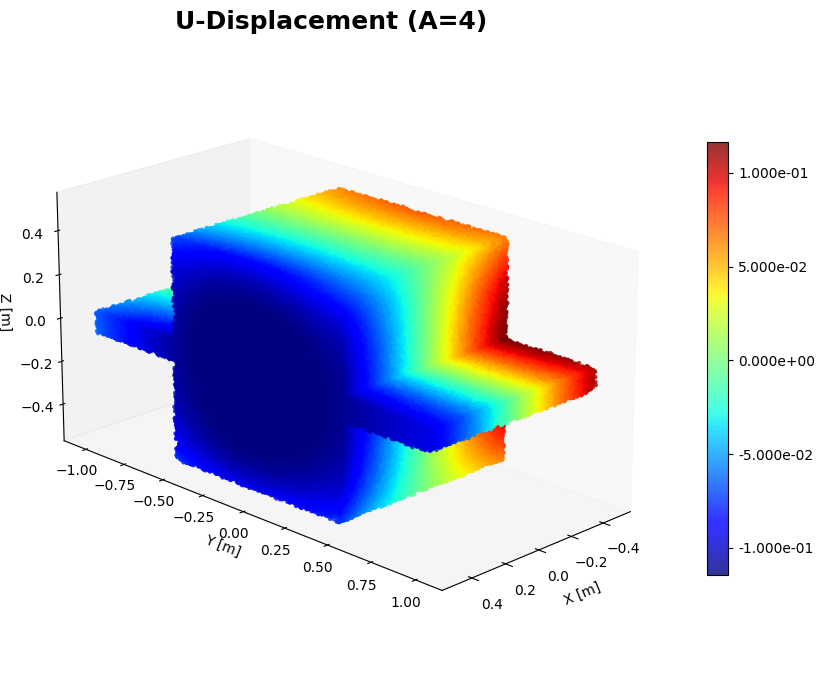

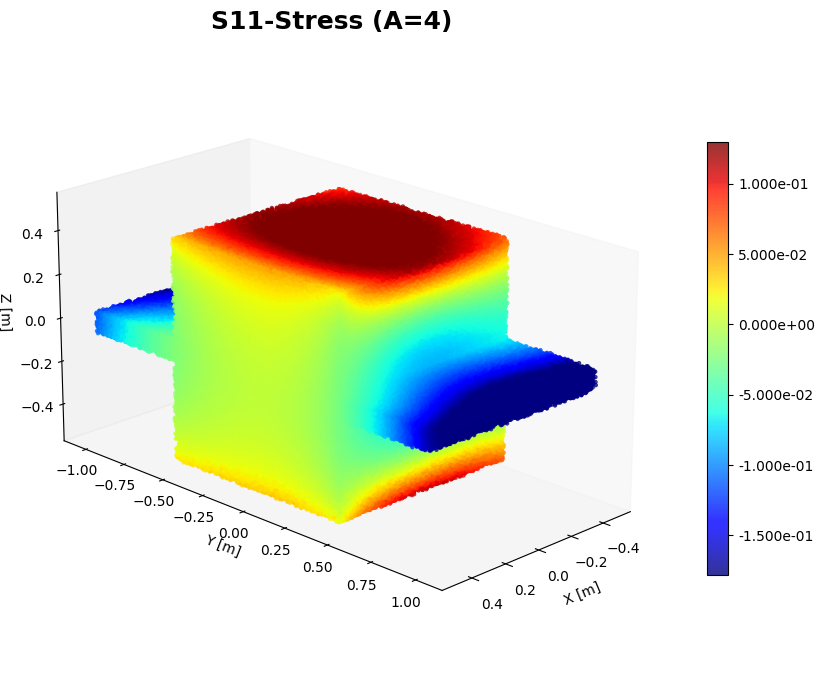

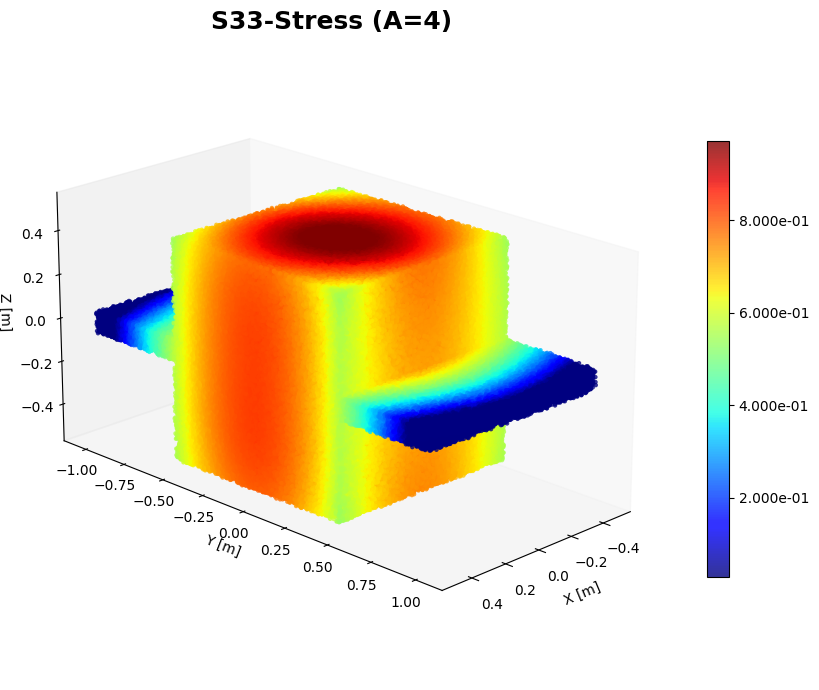

In [19]:
#!/usr/bin/env python
# coding: utf-8

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import math # 虽然在 A=4 的版本中用不到，但保留是个好习惯

# ==============================================================================
# ✨ 几何生成模块代码，直接内嵌在此处 ✨
# ==============================================================================
def generate_winged_block_mesh(n_interior=5000, n_boundary_face=500):
    """
    生成一个“带翅膀的方块”几何体的网格点。
    主体为正方体，翅膀更薄。
    """
    main_x, main_y, main_z = [-0.5, 0.5], [-0.5, 0.5], [-0.5, 0.5]
    wing_x, wing_y_left, wing_y_right, wing_z = [-0.5, 0.5], [-1.0, -0.5], [0.5, 1.0], [-0.05, 0.05]
    def is_inside(p):
        x, y, z = p[:, 0], p[:, 1], p[:, 2]
        in_main = (x >= main_x[0]) & (x <= main_x[1]) & (y >= main_y[0]) & (y <= main_y[1]) & (z >= main_z[0]) & (z <= main_z[1])
        in_left_wing = (x >= wing_x[0]) & (x <= wing_x[1]) & (y >= wing_y_left[0]) & (y <= wing_y_left[1]) & (z >= wing_z[0]) & (z <= wing_z[1])
        in_right_wing = (x >= wing_x[0]) & (x <= wing_x[1]) & (y >= wing_y_right[0]) & (y <= wing_y_right[1]) & (z >= wing_z[0]) & (z <= wing_z[1])
        return in_main | in_left_wing | in_right_wing
    bounding_box = np.array([[main_x[0], main_x[1]], [wing_y_left[0], wing_y_right[1]], [main_z[0], main_z[1]]])
    interior_points = []
    while len(interior_points) < n_interior:
        points = bounding_box[:, 0] + (bounding_box[:, 1] - bounding_box[:, 0]) * np.random.rand((n_interior - len(interior_points)) * 2, 3)
        interior_points.extend(points[is_inside(points)])
    x_interior = np.array(interior_points[:n_interior])
    def generate_face_points(n_pts, fixed_dim, fixed_val, r1, r2):
        pts = np.random.rand(n_pts, 2); pts[:, 0] = r1[0] + (r1[1] - r1[0]) * pts[:, 0]; pts[:, 1] = r2[0] + (r2[1] - r2[0]) * pts[:, 1]
        full_pts = np.full((n_pts, 3), fixed_val); dims = [0,1,2]; data_dims = [d for d in dims if d != fixed_dim]
        full_pts[:, data_dims[0]] = pts[:, 0]; full_pts[:, data_dims[1]] = pts[:, 1]; return full_pts
    x1u = generate_face_points(n_boundary_face, 0, main_x[1], main_y, main_z); x1b = generate_face_points(n_boundary_face, 0, main_x[0], main_y, main_z)
    x2u = generate_face_points(n_boundary_face, 1, wing_y_right[1], wing_x, wing_z); x2b = generate_face_points(n_boundary_face, 1, wing_y_left[0], wing_x, wing_z)
    n_main = int(n_boundary_face * 0.7); n_wing = (n_boundary_face - n_main) // 2
    n_wing_rem = n_boundary_face - n_main - n_wing
    x3u_main = generate_face_points(n_main, 2, main_z[1], main_x, main_y); x3u_lwing = generate_face_points(n_wing, 2, wing_z[1], wing_x, wing_y_left); x3u_rwing = generate_face_points(n_wing_rem, 2, wing_z[1], wing_x, wing_y_right); x3u = np.vstack([x3u_main, x3u_lwing, x3u_rwing])
    x3b_main = generate_face_points(n_main, 2, main_z[0], main_x, main_y); x3b_lwing = generate_face_points(n_wing, 2, wing_z[0], wing_x, wing_y_left); x3b_rwing = generate_face_points(n_wing_rem, 2, wing_z[0], wing_x, wing_y_right); x3b = np.vstack([x3b_main, x3b_lwing, x3b_rwing])
    return {'x': x_interior, 'x1u': x1u, 'x1b': x1b, 'x2u': x2u, 'x2b': x2b, 'x3u': x3u, 'x3b': x3b, 'n': np.array([[x_interior.shape[0]]])}

# 设置设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ==============================================================================
# 神经网络和数据集类 (A=4 固定版本)
# ==============================================================================
class MLP(nn.Module):
    def __init__(self, layers):
        super(MLP, self).__init__()
        modules = []
        for i in range(len(layers)-2):
            modules.append(nn.Linear(layers[i], layers[i+1]))
            modules.append(nn.Tanh())
        modules.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*modules)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)

class CustomDataset(Dataset):
    def __init__(self, batch_size, **kwargs):
        self.x = torch.tensor(kwargs['x'], dtype=torch.float32).to(device)
        self.x1u, self.x1b = torch.tensor(kwargs['x1u'], dtype=torch.float32).to(device), torch.tensor(kwargs['x1b'], dtype=torch.float32).to(device)
        self.x2u, self.x2b = torch.tensor(kwargs['x2u'], dtype=torch.float32).to(device), torch.tensor(kwargs['x2b'], dtype=torch.float32).to(device)
        self.x3u, self.x3b = torch.tensor(kwargs['x3u'], dtype=torch.float32).to(device), torch.tensor(kwargs['x3b'], dtype=torch.float32).to(device)
        self.batch_size = batch_size
        self.N = self.x.shape[0]
        x_top = self.x3u[:, 0]
        y_top = self.x3u[:, 1]
        
        # 定义一个峰值在中心(0,0)的二次函数
        # 形式为: MaxValue - (scale_x * x^2 + scale_y * y^2)
        max_value = 1.0
        
        # 通过平方和相减，实现中间高、四周低的效果
        self.target_boundary = (max_value - (x_top**2 + y_top**2)).to(device)
#         self.target_boundary = (self.x3u[:, 0] + self.x3u[:, 1]).to(device)
    def __len__(self):
        return self.N
    def __getitem__(self, idx):
        indices = torch.randperm(self.N, device=self.x.device)[:self.batch_size]
        return self.x[indices], self.x1u, self.x1b, self.x2u, self.x2b, self.x3u, self.x3b, self.target_boundary

# ==============================================================================
# 物理方程和模型 (A=4 固定版本)
# ==============================================================================
def material(*derivs, E=1.0, mu=0.25):
    u_x, u_y, u_z, u_xx, u_xy, u_xz, u_yy, u_yz, u_zz, \
    v_x, v_y, v_z, v_xx, v_xy, v_xz, v_yy, v_yz, v_zz, \
    w_x, w_y, w_z, w_xx, w_xy, w_xz, w_yy, w_yz, w_zz = derivs
    la = E * mu / (1 + mu) / (1 - 2 * mu); G = E / (1 + mu) / 2
    e1,e2,e3 = u_x, v_y, w_z; e12,e23,e13 = 0.5*(u_y+v_x), 0.5*(w_y+v_z), 0.5*(u_z+w_x)
    s1,s2,s3 = (2*G+la)*e1+la*e2+la*e3, (2*G+la)*e2+la*e1+la*e3, (2*G+la)*e3+la*e1+la*e2
    s12,s23,s13 = 2*G*e12, 2*G*e23, 2*G*e13
    Gex = (G+la)*(u_xx+v_xy+w_xz) + G*(u_xx+u_yy+u_zz)
    Gey = (G+la)*(v_yy+u_xy+w_yz) + G*(v_xx+v_yy+v_zz)
    Gez = (G+la)*(w_zz+u_xz+v_yz) + G*(w_xx+w_yy+w_zz)
    return e1, e2, e3, e12, e23, e13, s1, s2, s3, s12, s23, s13, Gex, Gey, Gez

class MultiFNN(nn.Module):
    def __init__(self, layers):
        super(MultiFNN, self).__init__()
        self.u_net = MLP(layers).to(device)
        self.v_net = MLP(layers).to(device)
        self.w_net = MLP(layers).to(device)
        self.loss_log = []

    def u_model(self, x, y, z): return self.u_net(torch.stack([x, y, z], dim=-1)).squeeze(-1) * x
    def v_model(self, x, y, z): return self.v_net(torch.stack([x, y, z], dim=-1)).squeeze(-1) * y
    def w_model(self, x, y, z): return self.w_net(torch.stack([x, y, z], dim=-1)).squeeze(-1) * z

    def compute_derivatives(self, x, y, z):
        x.requires_grad_(True); y.requires_grad_(True); z.requires_grad_(True)
        u, v, w = self.u_model(x, y, z), self.v_model(x, y, z), self.w_model(x, y, z)
        grad_u = torch.autograd.grad(u, (x,y,z), torch.ones_like(u), create_graph=True); u_x, u_y, u_z = grad_u
        grad_v = torch.autograd.grad(v, (x,y,z), torch.ones_like(v), create_graph=True); v_x, v_y, v_z = grad_v
        grad_w = torch.autograd.grad(w, (x,y,z), torch.ones_like(w), create_graph=True); w_x, w_y, w_z = grad_w
        u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
        u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
        u_zz = torch.autograd.grad(u_z, z, torch.ones_like(u_z), create_graph=True)[0]
        u_xy = torch.autograd.grad(u_x, y, torch.ones_like(u_x), create_graph=True)[0]
        u_xz = torch.autograd.grad(u_x, z, torch.ones_like(u_x), create_graph=True)[0]
        u_yz = torch.autograd.grad(u_y, z, torch.ones_like(u_y), create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
        v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v_y), create_graph=True)[0]
        v_zz = torch.autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
        v_xy = torch.autograd.grad(v_x, y, torch.ones_like(v_x), create_graph=True)[0]
        v_xz = torch.autograd.grad(v_x, z, torch.ones_like(v_x), create_graph=True)[0]
        v_yz = torch.autograd.grad(v_y, z, torch.ones_like(v_y), create_graph=True)[0]
        w_xx = torch.autograd.grad(w_x, x, torch.ones_like(w_x), create_graph=True)[0]
        w_yy = torch.autograd.grad(w_y, y, torch.ones_like(w_y), create_graph=True)[0]
        w_zz = torch.autograd.grad(w_z, z, torch.ones_like(w_z), create_graph=True)[0]
        w_xy = torch.autograd.grad(w_x, y, torch.ones_like(w_x), create_graph=True)[0]
        w_xz = torch.autograd.grad(w_x, z, torch.ones_like(w_x), create_graph=True)[0]
        w_yz = torch.autograd.grad(w_y, z, torch.ones_like(w_y), create_graph=True)[0]
        return (u_x,u_y,u_z,u_xx,u_xy,u_xz,u_yy,u_yz,u_zz, v_x,v_y,v_z,v_xx,v_xy,v_xz,v_yy,v_yz,v_zz, w_x,w_y,w_z,w_xx,w_xy,w_xz,w_yy,w_yz,w_zz)

    def forward(self, batch):
        x, x1u, x1b, x2u, x2b, x3u, x3b, y = batch
        derivs = self.compute_derivatives(x[:, 0], x[:, 1], x[:, 2])
        *_, Gex, Gey, Gez = material(*derivs)
        s = [material(*self.compute_derivatives(b[:, 0], b[:, 1], b[:, 2])) for b in [x1u, x1b, x2u, x2b, x3u, x3b]]
        l1 = torch.mean(Gex**2) + torch.mean(Gey**2) + torch.mean(Gez**2)
        lx = torch.mean(s[0][6]**2) + torch.mean(s[0][9]**2) + torch.mean(s[0][11]**2) + torch.mean(s[1][9]**2) + torch.mean(s[1][11]**2)
        ly = torch.mean(s[2][7]**2) + torch.mean(s[2][9]**2) + torch.mean(s[2][10]**2) + torch.mean(s[3][9]**2) + torch.mean(s[3][10]**2)
        lz = torch.mean((s[4][8]-y)**2) + torch.mean(s[4][10]**2) + torch.mean(s[4][11]**2) + torch.mean(s[5][10]**2) + torch.mean(s[5][11]**2)
        loss = l1 + lx + ly + lz
        return loss, l1, lx, ly, lz

# ==============================================================================
# 预测、训练和绘图函数
# ==============================================================================
def predict(self, x_coords, batch_size=10000):
    self.eval(); u, v, w = [np.zeros(x_coords.shape[0]) for _ in range(3)]
    with torch.no_grad():
        for i in range(0, x_coords.shape[0], batch_size):
            end = min(i + batch_size, x_coords.shape[0])
            xb = torch.tensor(x_coords[i:end], dtype=torch.float32).to(device)
            u[i:end], v[i:end], w[i:end] = self.u_model(xb[:,0],xb[:,1],xb[:,2]).cpu().numpy(), self.v_model(xb[:,0],xb[:,1],xb[:,2]).cpu().numpy(), self.w_model(xb[:,0],xb[:,1],xb[:,2]).cpu().numpy()
    self.train(); return u, v, w
MultiFNN.predict = predict

def predict_stress(self, x_coords, batch_size=10000):
    self.eval() 
    stresses = [np.empty(x_coords.shape[0], dtype=np.float32) for _ in range(6)]
    # ✨ 关键修复：移除 with torch.no_grad()
    for i in range((x_coords.shape[0] + batch_size - 1) // batch_size):
        start, end = i * batch_size, min((i + 1) * batch_size, x_coords.shape[0])
        xb = torch.tensor(x_coords[start:end], dtype=torch.float32).to(device)
        derivs = self.compute_derivatives(xb[:,0], xb[:,1], xb[:,2])
        s = material(*derivs)
        for j in range(6): 
            stresses[j][start:end] = s[j+6].detach().cpu().numpy()
    self.train()
    return tuple(stresses)
MultiFNN.predict_stress = predict_stress

def train_model(model, dataset, n_iter=10000, lr=1e-3):
    print("开始训练模型 (固定 A=4)...")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
    pbar = tqdm(range(n_iter))
    for it in pbar:
        model.train(); batch = dataset[0]
        loss, l1, lx, ly, lz = model(batch)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if it > 0 and it % 2000 == 0: scheduler.step()
        if it % 10 == 0:
            pbar.set_postfix({'Loss': f"{loss.item():.2e}", 'l1_res': f"{l1.item():.2e}"})
            model.loss_log.append(loss.item())

def plot_results_3d(vc, x, title):
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(projection='3d')

    # 绘制所有点，不进行采样
    plot_every = 1
    x_plot, vc_plot = x[::plot_every], vc[::plot_every]

    vmax, vmin = np.percentile(vc_plot, 99), np.percentile(vc_plot, 1)

    # 极大增加点密度的设置
    im = ax.scatter(x_plot[:, 0], x_plot[:, 1], x_plot[:, 2],
                    c=vc_plot, cmap='jet', vmin=vmin, vmax=vmax, 
                    s=10,           # 进一步增加点大小到50
                    alpha=0.8,      # 添加透明度，让重叠区域更明显
                    edgecolors='none',  # 去除点的边缘线，让点更紧密
                    rasterized=True)    # 栅格化渲染，提高性能

    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_box_aspect((np.ptp(x_plot[:, 0]), np.ptp(x_plot[:, 1]), np.ptp(x_plot[:, 2])))
    
    # 优化颜色条
    fig.colorbar(im, ax=ax, format='%.3e', fraction=0.02, shrink=0.8)
    
    # 移除网格线，让点更突出
    ax.grid(False)
    
    # 设置更好的视角
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()

# 在main函数中进一步增加测试点密度
def main():
    print("--- 求解器启动: 固定问题 (A=4) ---")
    training_mesh = generate_winged_block_mesh(n_interior=5000, n_boundary_face=600)
    dataset = CustomDataset(batch_size=training_mesh['n'][0,0], **training_mesh)
    layers = [3, 20, 20, 20, 20, 1]
    model = MultiFNN(layers).to(device)

    if input("是否训练新模型? (y/n): ").lower() == 'y':
        n_iter = int(input("请输入训练迭代次数 (建议: 10000): ") or "10000")
        train_model(model, dataset, n_iter=n_iter)
        if input("是否保存模型? (y/n): ").lower() == 'y':
            torch.save(model.state_dict(), 'winged_block_model_A4.pt')
            print("模型已保存到 'winged_block_model_A4.pt'")
    else:
        model_path = 'winged_block_model_A4.pt'
        try:
            model.load_state_dict(torch.load(model_path))
            print(f"模型已从 '{model_path}' 加载。")
        except FileNotFoundError:
            print(f"错误: 找不到模型文件 {model_path}。请先训练一个模型。")
            return
            
    print("\n正在生成用于可视化的超密集测试点...")
    # 大幅增加测试点数量以获得更密集的可视化
    test_mesh = generate_winged_block_mesh(n_interior=1000000, n_boundary_face=2000)  # 从25000增加到50000+
    test_x = test_mesh['x']
    
    print(f"测试点总数: {len(test_x)}")
    print("开始预测 (固定 A=4)...")
    u, v, w = model.predict(test_x)
    s1, s2, s3, s12, s23, s13 = model.predict_stress(test_x)

    print("绘制结果云图...")
    plot_results_3d(u, test_x, 'U-Displacement (A=4)')
    plot_results_3d(s1, test_x, 'S11-Stress (A=4)')
    plot_results_3d(s3, test_x, 'S33-Stress (A=4)')

if __name__ == "__main__":
    main()